#### 5.3 Gradient Desecent

**실제 값은 $y=4x+6$ 시뮬레이션하는 데이터 값 생성**

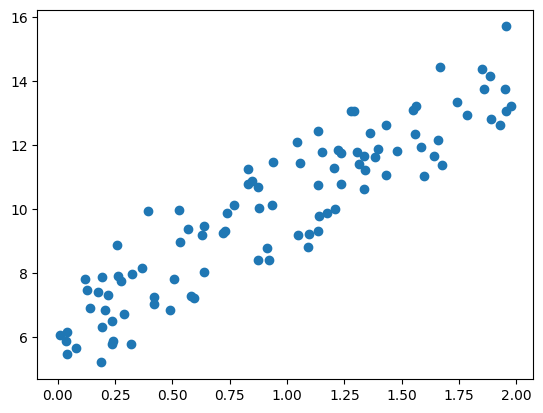

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

np.random.seed(0)

# y = 4x + 6 식을 근사 (w1 = 4, w0 = 6), random 값은 Noise를 위해 만듦
X = 2 * np.random.rand(100, 1)
y = 6 + 4 * X + np.random.randn(100, 1)

plt.scatter(X,y)


In [3]:
X.shape, y.shape

((100, 1), (100, 1))

In [ ]:
# w1과 w0를 업데이트 할 w1_update, w0_update를 반환
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)
    
    # 먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    
    # 예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X, w1.T) + w0
    diff = y - y_pred
    
    # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    w0_factors = np.ones((N, 1)) # (100, 1)
    
    # w1과 w0을 업데이트할 w1_update와 w0_update 계산
    w1_update = -(2/N) * learning_rate * (np.dot(X.T, diff))
    w0_update = -(2/N) * learning_rate * (np.dot(w0_factors.T, diff))

    return w1_update, w0_update



In [11]:
w0 = np.zeros((1, 1))
print(w0)
w1 = np.zeros((1, 1))
print(w1)
y_pred = np.dot(X, w1.T) + w0
diff = y - y_pred
print(diff.shape)
w0_factors = np.ones((100, 1))
w1_update = -(2/100) * 0.01 * (np.dot(X.T, diff))
w0_update = -(2/100) * 0.01 * (np.dot(w0_factors.T, diff))
print(w1_update.shape, w0_update.shape)

[[0.]]
[[0.]]
(100, 1)
(1, 1) (1, 1)


**반복적으로 경사 하강법을 이용하여 get_weight_updates()를 호출하여 w1과 w0를 업데이트 하는 함수 생성**

In [13]:
def gradient_descent_steps(X, y, iters=10000):
    # w0와 w1을 모두 0으로 초기화
    w1 = np.zeros((1, 1))
    w0 = np.zeros((1, 1))
    
    # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출하여 w1, w0 업데이트 수행
    for _ in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    
    return w1, w0

**예측 오차 비용을 계산을 수행하는 함수 생성 및 경사 하강법 수행**

In [19]:
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

w1, w0 = gradient_descent_steps(X, y, iters=1000)
print("w1 : {0:.4f} w0 : {1:.4f}".format(w1[0, 0], w0[0,0]))
y_pred = w1[0, 0] * X + w0
print("Gradient Descent Total Cost : {0:.4f} ".format(get_cost(y, y_pred)))

w1 : 4.0218 w0 : 6.1620
Gradient Descent Total Cost : 0.9935 


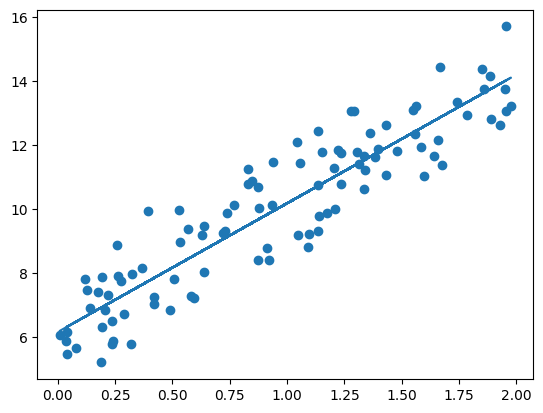

In [20]:
plt.scatter(X, y)
plt.plot(X, y_pred)

**미니 배치 확률적 경사 하강법을 이용한 최적 비용함수 도출**